# Post-Quantum KEM Performance Analysis

This Jupyter Notebook focuses on the performance evaluation of various Post-Quantum Cryptography (**PQC**) Key Encapsulation Mechanisms (**KEMs**), specifically those selected during the NIST PQC standardization process. It precisely measures **key generation times** and the **sizes of public and private keys** across different [**NIST security levels**](https://csrc.nist.rip/groups/ST/post-quantum-crypto/evaluation-criteria.html). The collected data, including key sizes and security levels which can also be referenced from the [**Botan**](https://botan.randombit.net/handbook/) documentation, are clearly presented in tables and charts. The overarching goal is to assess the practical applicability of these forward-looking PQC algorithms based on their performance. While AES is included for comparison because its security levels correspond to the NIST PQC levels and it is also considered secure against quantum attacks, it's crucial to note that as a symmetric encryption algorithm, its fundamental operation differs significantly from asymmetric KEMs, making a direct comparison regarding key generation and size challenging. ![Key Encapsulation Mechanisms](https://examroom.ai/blog/wp-content/uploads/2024/04/low-res-open_2-1-1.png)

## Table of Contents
- [Requirements](#requirements)
- [Code](#code)
- [Output](#output)
    - [Level 1](#l1)
    - [Level 2](#l2)
    - [Level 3](#l3)
- [Conclusion](#conclusion)

## Requirements <a id="requirements"></a>

In [1]:
import sys
!"{sys.executable}" -m pip install -q -r requirements.txt

In [2]:
import os
import sys
import timeit
import pandas as pd
import ctypes
from Crypto.Cipher import AES
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = os.getcwd()
os.environ['PATH'] = current_dir + os.pathsep + os.environ['PATH']
sys.path.append(current_dir)
#dll_path for Windows "botan-3.dll"
dll_path = os.path.join(current_dir, "libbotan-3.so.10") #for Linux
botan_dll = ctypes.CDLL(dll_path)
import botan3 as botan

In [3]:
# Panda options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

encryption_L1 = ["ML-KEM", "FrodoKEM", "AES-128"]  # ML-KEM-512 equivalent, FrodoKEM-640 equivalent
encryption_L3 = ["Kyber", "FrodoKEM", "AES-192"]   # ML-KEM-768/Kyber768 equivalent, FrodoKEM-976 equivalent
encryption_L5 = ["ML-KEM", "FrodoKEM", "McEliece", "AES-256"]  # ML-KEM-1024 equivalent, FrodoKEM-1344 equivalent

test_runs = 1000

## Code <a id="code"></a>

In [4]:
# Functions
def generate_keys(algorithm, security_level):
    rng = botan.RandomNumberGenerator()
    
    if algorithm.startswith("AES"):
        key_bytes = int(algorithm.split('-')[1]) // 8
        key = rng.get(key_bytes)
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Public Key (hex)': "Not available", 'Public Key length': 0,
            'Secret Key (hex)': key.hex(), 'Secret Key length': len(key)}, None
    
    else:
        private_key = botan.PrivateKey.create(algorithm, "", rng)
        public_key = private_key.get_public_key()
        
        public_key_bin = public_key.to_raw()
        private_key_bin = b"Private key raw export not supported"
        
        try:
            private_key_bin = private_key.to_raw()
        except:
            pass
        
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Public Key (hex)': public_key_bin.hex(), 'Public Key length': len(public_key_bin),
            'Secret Key (hex)': private_key_bin.hex(), 'Secret Key length': len(private_key_bin)}, private_key

def encryption(algorithm, security_level, public_key_client):
    rng = botan.RandomNumberGenerator()
    
    if algorithm.startswith("AES"):
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Ciphertext (hex)': "Not available", 'Ciphertext length': 0,
            'Shared Secret Sender': "Not available", 'Shared Secret Sender length': 0}
    
    encryptor = botan.KemEncrypt(public_key_client, "KDF2(SHA-256)")
    salt = b""
    desired_key_len = 32
    shared_key, encapsulated_key = encryptor.create_shared_key(rng, salt, desired_key_len)
    
    return { 'Algorithm': algorithm, 'Security Level': security_level,
        'Ciphertext (hex)': encapsulated_key.hex(), 'Ciphertext length': len(encapsulated_key),
        'Shared Secret Sender': shared_key.hex(), 'Shared Secret Sender length': len(shared_key)}

def decryption(algorithm, security_level, private_key, ciphertext):
    if algorithm.startswith("AES"):
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Shared Secret Receiver': "Not available", 'Shared Secret Receiver length': 0}
    
    decryptor = botan.KemDecrypt(private_key, "KDF2(SHA-256)")
    salt = b""
    desired_key_len = 32
    shared_key = decryptor.decrypt_shared_key(salt, desired_key_len, ciphertext)
    
    return { 'Algorithm': algorithm, 'Security Level': security_level,
        'Shared Secret Receiver': shared_key.hex(), 'Shared Secret Receiver length': len(shared_key)}

def times_to_df(algorithm: str, execution_times: list, security_level: str, operation_type: str) -> pd.DataFrame:
    avg_time = sum(execution_times) / len(execution_times)
    min_time = min(execution_times)
    max_time = max(execution_times)
    data = {
        'Algorithm': [algorithm],
        'Security Level': [security_level],
        'Operation': [operation_type],
        'Min_Time (s)': [min_time], 
        'Average_Time (s)': [avg_time], 
        'Max_Time (s)': [max_time] 
    }
    return pd.DataFrame(data)

def measure_execution_times(func, num_runs, *func_args):
    times = timeit.repeat(lambda: func(*func_args), number=1, repeat=num_runs)
    return times
    
def process_encryption_level(algorithms_list: list, runs: int, level_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    keys_data_list = []
    key_times_list = []
    encryption_data_list = []
    encryption_times_list = []
    decryption_data_list = []
    decryption_times_list = []

    for alg in algorithms_list:
        print(f"Processing {alg}...")
        
        try:
            # Generate keys and measure time
            keys_info, private_key = generate_keys(alg, level_name)
            keys_data_list.append(keys_info)

            times_keys = measure_execution_times(generate_keys, runs, alg, level_name)
            time_df_keys = times_to_df(alg, times_keys, level_name, "Key Generation")
            key_times_list.append(time_df_keys)

            if not alg.startswith("AES") and private_key is not None:
                # Get the public key from the private key
                public_key = private_key.get_public_key()
                
                try:
                    # Encryption and measure time
                    encryption_data = encryption(alg, level_name, public_key)
                    encryption_data_list.append(encryption_data)

                    times_encryption = measure_execution_times(encryption, runs, alg, level_name, public_key)
                    time_df_encryption = times_to_df(alg, times_encryption, level_name, "Encryption")
                    encryption_times_list.append(time_df_encryption)

                    # Get ciphertext for decryption
                    if encryption_data['Ciphertext (hex)'] != "Not available":
                        ciphertext_to_decap = encryption_data['Ciphertext (hex)']
                        ciphertext_bytes = bytes.fromhex(ciphertext_to_decap)

                        try:
                            # Decryption and measure time
                            decryption_data = decryption(alg, level_name, private_key, ciphertext_bytes)
                            decryption_data_list.append(decryption_data)

                            # Verify shared secrets match
                            shared_secret_sender = encryption_data['Shared Secret Sender']
                            shared_secret_receiver = decryption_data['Shared Secret Receiver']
                            
                            if shared_secret_sender == shared_secret_receiver:
                                print(f"Shared Secret for {alg} ({level_name}) matches: True")
                            else:
                                print(f"Shared Secret for {alg} ({level_name}) matches: False") 

                            times_decryption = measure_execution_times(decryption, runs, alg, level_name, private_key, ciphertext_bytes)
                            time_df_decryption = times_to_df(alg, times_decryption, level_name, "Decryption")
                            decryption_times_list.append(time_df_decryption)
                        except Exception as e:
                            print(f"Error in decryption for {alg}: {str(e)}")
                except Exception as e:
                    print(f"Error in encryption for {alg}: {str(e)}")
        except Exception as e:
            print(f"Error in key generation for {alg}: {str(e)}")
            continue

    # Create DataFrames from the collected data
    df_keys = pd.DataFrame(keys_data_list)
    df_time_keys = pd.concat(key_times_list, ignore_index=True) if key_times_list else pd.DataFrame()
    df_encryption = pd.DataFrame(encryption_data_list) if encryption_data_list else pd.DataFrame({'Algorithm': [], 'Security Level': [], 'Ciphertext (hex)': [], 'Ciphertext length': [], 'Shared Secret Sender': [], 'Shared Secret Sender length': []})
    df_time_encryption = pd.concat(encryption_times_list, ignore_index=True) if encryption_times_list else pd.DataFrame({'Algorithm': [], 'Security Level': [], 'Operation': [], 'Min_Time (s)': [], 'Average_Time (s)': [], 'Max_Time (s)': []})
    df_decryption = pd.DataFrame(decryption_data_list) if decryption_data_list else pd.DataFrame({'Algorithm': [], 'Security Level': [], 'Shared Secret Receiver': [], 'Shared Secret Receiver length': []})
    df_time_decryption = pd.concat(decryption_times_list, ignore_index=True) if decryption_times_list else pd.DataFrame({'Algorithm': [], 'Security Level': [], 'Operation': [], 'Min_Time (s)': [], 'Average_Time (s)': [], 'Max_Time (s)': []})

    return df_keys, df_time_keys, df_encryption, df_time_encryption, df_decryption, df_time_decryption   

In [5]:
#show Results

def display_results(level_name: str, df: pd.DataFrame, description: str):
    print(f"\n--- {description} ({level_name}) ---") 
    print(df)

def plot_key_length_comparison(df_keys_all: pd.DataFrame):
    print("\n--- Plot: Key Lengths ---")

    df_keys_all_melted = df_keys_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=['Public Key length', 'Secret Key length'],
        var_name='Key Type',
        value_name='Length (Bytes)'
    )

    df_keys_all_melted_filtered = df_keys_all_melted[df_keys_all_melted['Length (Bytes)'] > 0].copy()

    level_order = ["L1", "L3", "L5", "Unknown"]

    df_keys_all_melted_filtered.loc[:, 'Security Level'] = pd.Categorical(
        df_keys_all_melted_filtered['Security Level'], categories=level_order, ordered=True
    )

    df_keys_all_melted_filtered = df_keys_all_melted_filtered.sort_values(
        ['Security Level', 'Algorithm']
    )

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_keys_all_melted_filtered,
        x='Algorithm',
        y='Length (Bytes)',
        hue='Key Type'
    )
    plt.title('Key Lengths in Bytes per Algorithm') # Translated title
    plt.xlabel('Algorithm') # Translated label
    plt.ylabel('Length (Bytes)') # Translated label
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Key Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_timing_comparison(df_time_all: pd.DataFrame, runs: int, title_suffix: str, level: str): 
    print(f"\n--- Plot: {title_suffix} Times ---") 

    # Check if DataFrame is empty or doesn't have required columns
    if df_time_all.empty or not all(col in df_time_all.columns for col in ['Algorithm', 'Security Level', 'Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)']):
        print("No data available for plotting")
        return
    
    try:
        df_time_all_melted = df_time_all.melt(
            id_vars=['Algorithm', 'Security Level'],
            value_vars=['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)'],
            var_name='Time Metric',
            value_name='Time (s)' 
        )

        level_order = ["L1", "L3", "L5", "Unknown"]
        df_time_all_melted.loc[:, 'Security Level'] = pd.Categorical(
            df_time_all_melted['Security Level'], categories=level_order, ordered=True
        )
        df_time_all_melted = df_time_all_melted.sort_values(
            ['Security Level', 'Algorithm']
        )

        plt.figure(figsize=(15, 8))
        sns.barplot(
            data=df_time_all_melted,
            x='Algorithm',
            y='Time (s)', 
            hue='Time Metric', 
        )
        plt.title(f'{title_suffix} Times per Algorithm (L{level}) (Min, Average, Max over {runs} Runs)') 
        plt.xlabel('Algorithm') 
        plt.ylabel('Time (s) (Log Scale)') 
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Time Metric', bbox_to_anchor=(1.05, 1), loc='upper left') 
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.yscale('log')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting: {str(e)}")

## Output <a id="ouput"></a>

### Level 1 <a id="l1"></a>

In [6]:
print("\nLevel 1...")
df_keys_L1, df_time_keys_L1, df_encryption_L1,  df_time_encryption_L1, df_decryption_L1, df_time_decryption_L1 = process_encryption_level(encryption_L1, test_runs, "L1")


Level 1...
Processing ML-KEM...
Shared Secret for ML-KEM (L1) matches: True
Processing FrodoKEM...
Shared Secret for FrodoKEM (L1) matches: True
Processing AES-128...


In [7]:
display_results("L1", df_keys_L1, "Generated Keys")
display_results("L1", df_time_keys_L1, "Average Key Generation Times")


--- Generated Keys (L1) ---
  Algorithm Security Level  \
0    ML-KEM             L1   
1  FrodoKEM             L1   
2   AES-128             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [8]:
display_results("L1", df_encryption_L1, "Encryption Data")
display_results("L1", df_time_encryption_L1, "Average Encryption Times")


--- Encryption Data (L1) ---
  Algorithm Security Level  \
0    ML-KEM             L1   
1  FrodoKEM             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [9]:
display_results("L1", df_decryption_L1, "Decryption Data")
display_results("L1", df_time_decryption_L1, "Average Decryption Times")


--- Decryption Data (L1) ---
  Algorithm Security Level  \
0    ML-KEM             L1   
1  FrodoKEM             L1   

                                             Shared Secret Receiver  \
0  706931310071c14e51b620b428b53721c04ca6acda1f714198c3fd5511cb9dd9   
1  29411f14834d9889e4c3b350627880065c844b52a29c14f9c5c1fe5e396bebe7   

   Shared Secret Receiver length  
0                             32  
1                             32  

--- Average Decryption Times (L1) ---
  Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0    ML-KEM             L1  Decryption      0.000071          0.000162   
1  FrodoKEM             L1  Decryption      0.006501          0.008460   

   Max_Time (s)  
0      0.008513  
1      0.016233  



--- Plot: Key Lengths ---


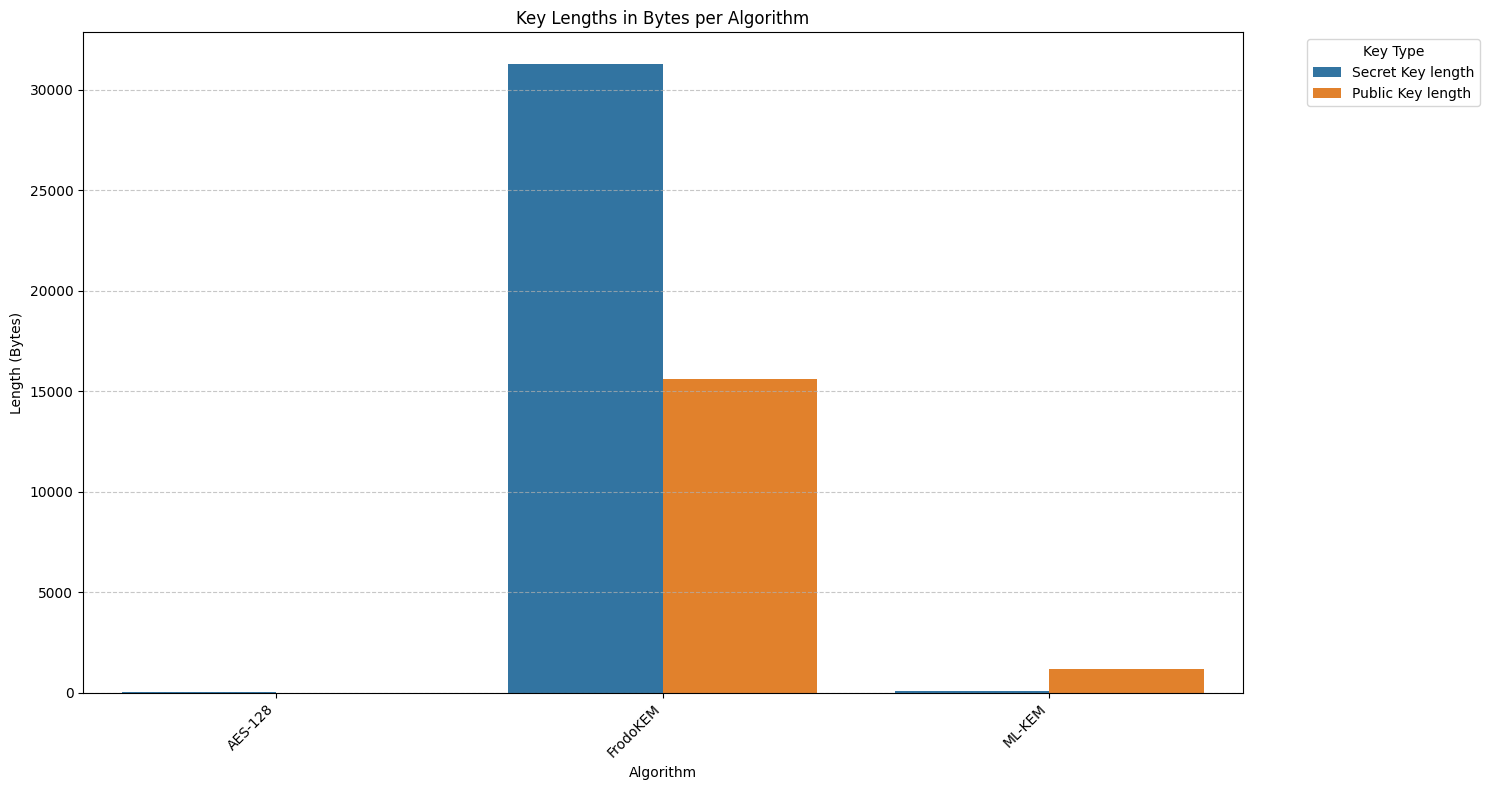

In [10]:
plot_key_length_comparison(df_keys_L1)


--- Plot: Key Generation Times ---


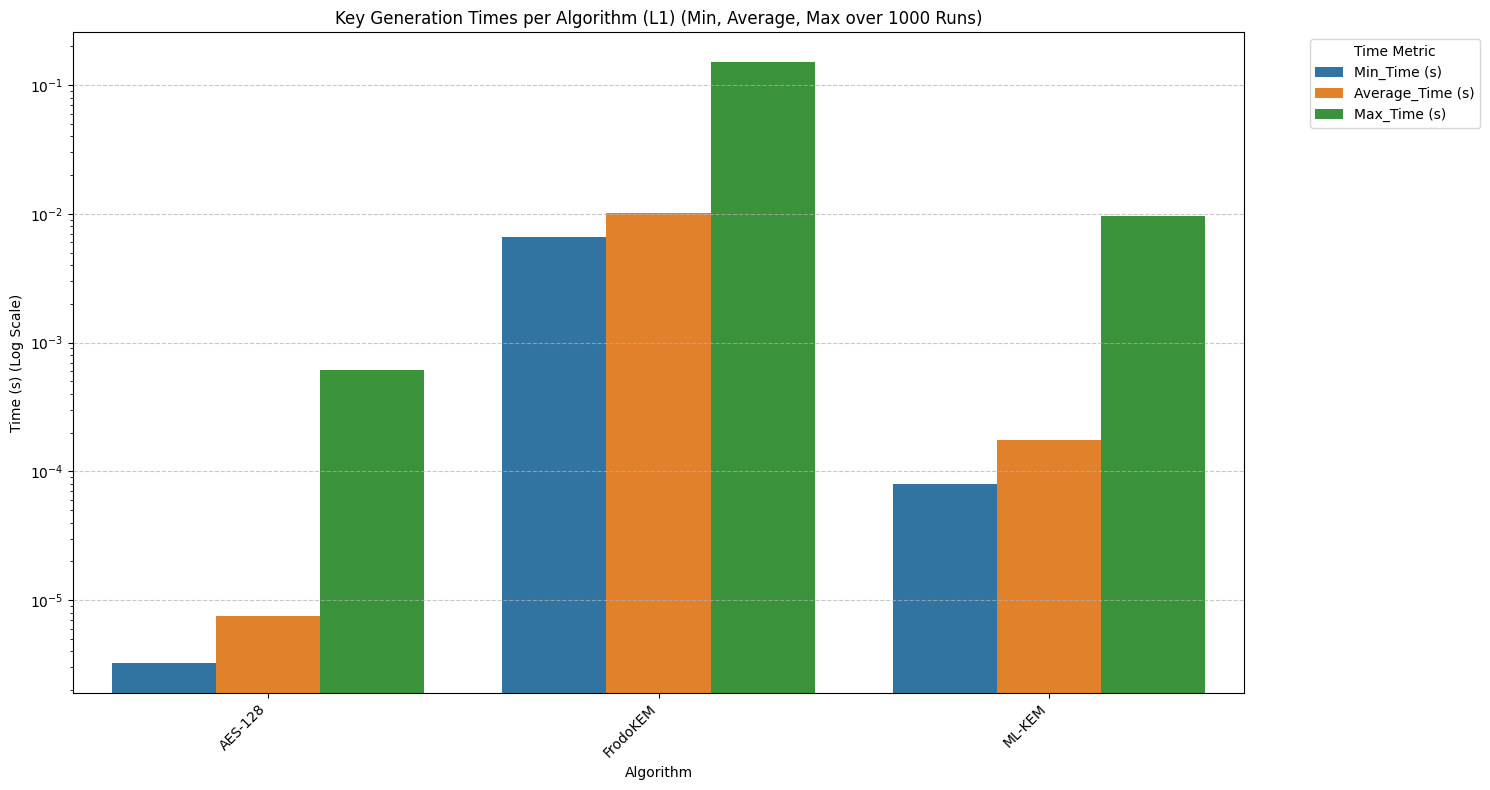

In [11]:
plot_timing_comparison(df_time_keys_L1, test_runs, "Key Generation", 1)


--- Plot: Encryption Times ---


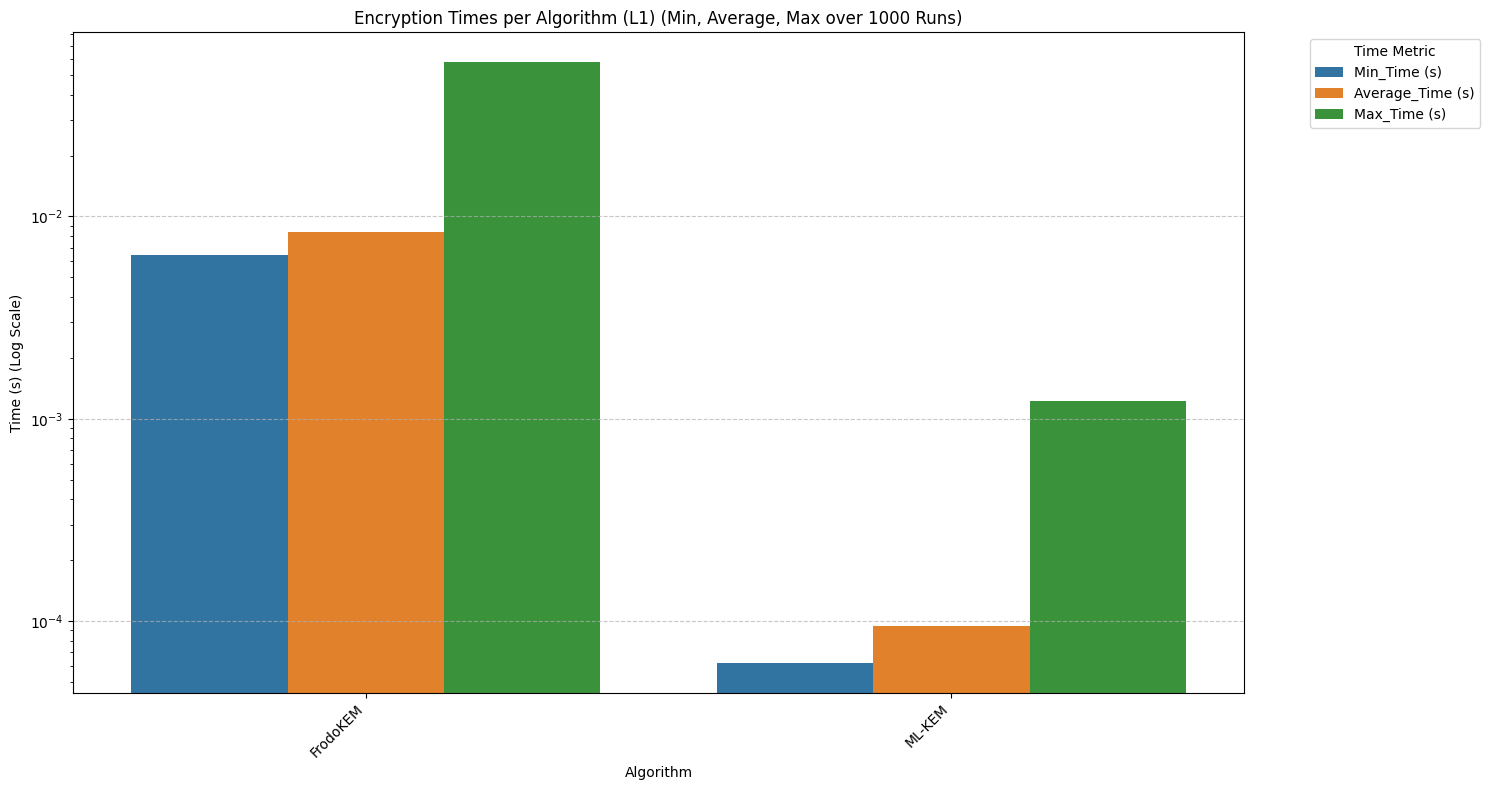

In [12]:
plot_timing_comparison(df_time_encryption_L1, test_runs, "Encryption", 1)


--- Plot: Decryption Times ---


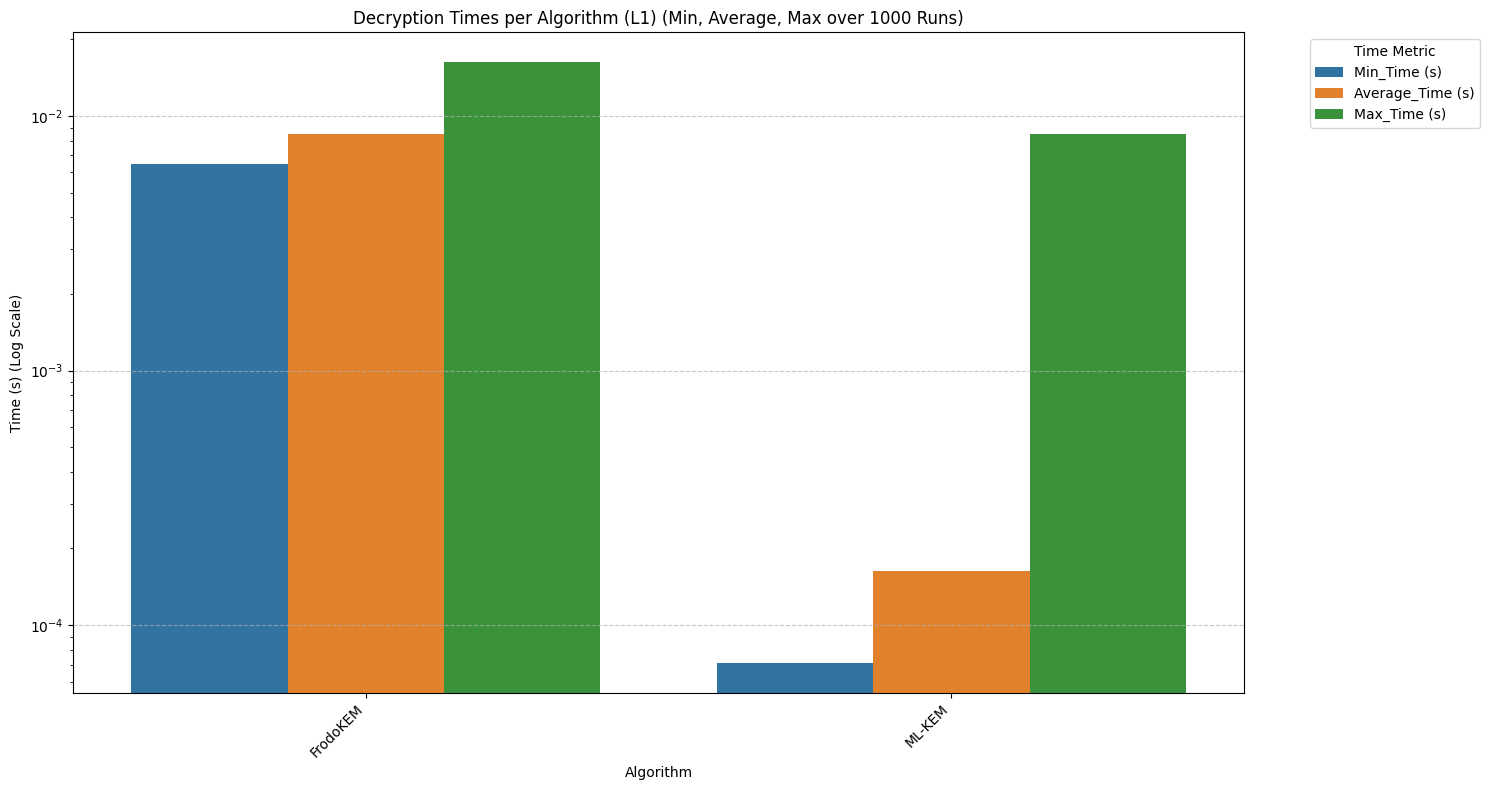

In [13]:
plot_timing_comparison(df_time_decryption_L1, test_runs, "Decryption", 1)

### Level 3 <a id="l3"></a>

In [14]:
print("\nLevel 3...")
df_keys_L3, df_time_keys_L3, df_encryption_L3, df_time_encryption_L3, df_decryption_L3, df_time_decryption_L3 = process_encryption_level(encryption_L3, test_runs, "L3")


Level 3...
Processing Kyber...
Shared Secret for Kyber (L3) matches: True
Processing FrodoKEM...
Shared Secret for FrodoKEM (L3) matches: True
Processing AES-192...


In [15]:
display_results("L3", df_keys_L3, "Generated Keys")
display_results("L3", df_time_keys_L3, "Average Key Generation Times")


--- Generated Keys (L3) ---
  Algorithm Security Level  \
0     Kyber             L3   
1  FrodoKEM             L3   
2   AES-192             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [16]:
display_results("L3", df_encryption_L3, "Encryption Data")
display_results("L3", df_time_encryption_L3, "Average Encryption Times")


--- Encryption Data (L3) ---
  Algorithm Security Level  \
0     Kyber             L3   
1  FrodoKEM             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [17]:
display_results("L3", df_decryption_L3, "Decryption Data")
display_results("L3", df_time_decryption_L3, "Average Decryption Times")


--- Decryption Data (L3) ---
  Algorithm Security Level  \
0     Kyber             L3   
1  FrodoKEM             L3   

                                             Shared Secret Receiver  \
0  6ca1662e1aceb148eb6554e665b5e8376a6e4a077d05852db9d602a0fbf574ca   
1  a530663d223740cd54c96e792fe103470ba685c8cfd36b038148143b7cc9bcd4   

   Shared Secret Receiver length  
0                             32  
1                             32  

--- Average Decryption Times (L3) ---
  Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0     Kyber             L3  Decryption      0.000105          0.000177   
1  FrodoKEM             L3  Decryption      0.006705          0.008806   

   Max_Time (s)  
0      0.012090  
1      0.026652  



--- Plot: Key Lengths ---


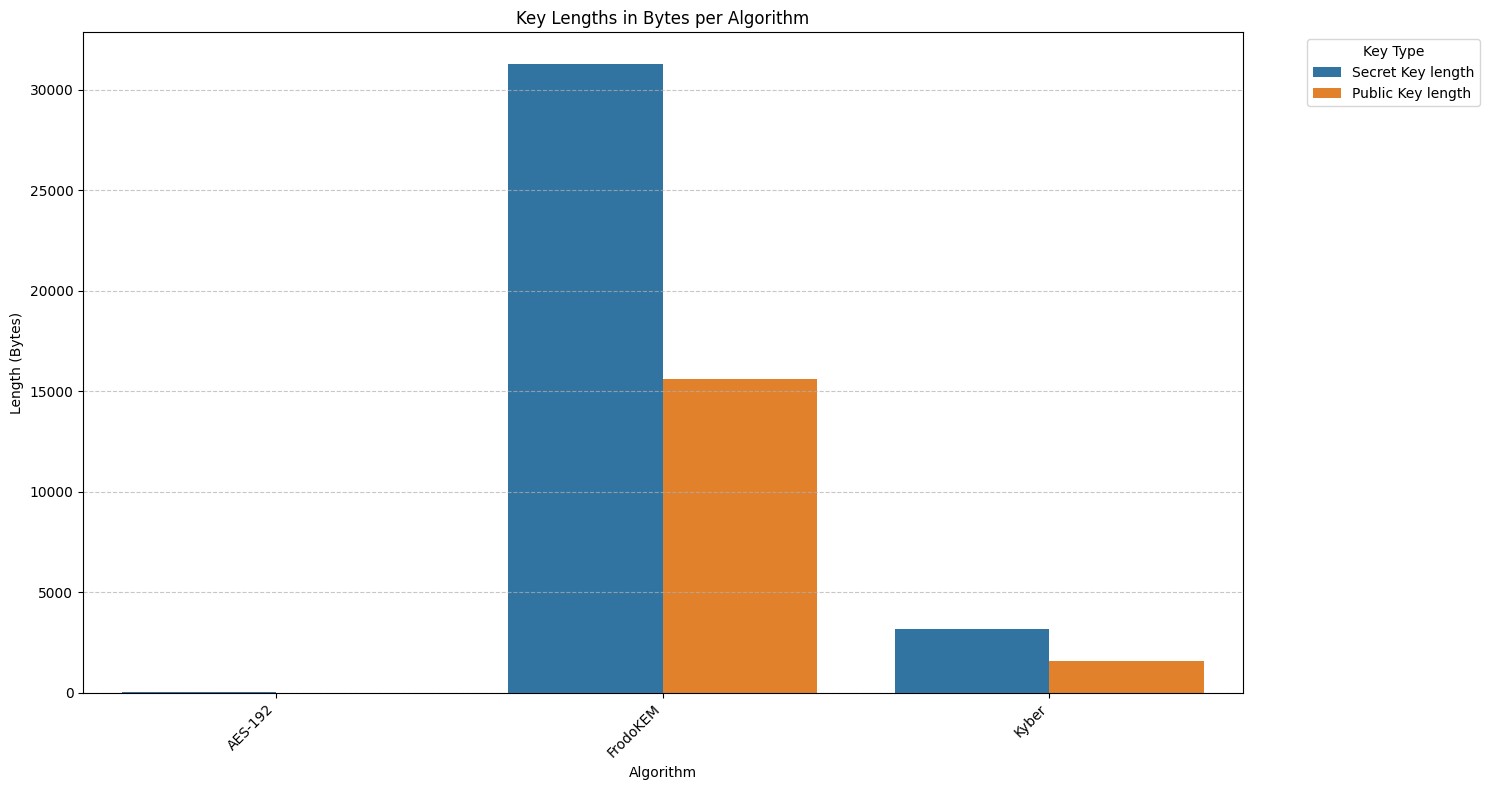

In [18]:
plot_key_length_comparison(df_keys_L3)


--- Plot: Key Generation Times ---


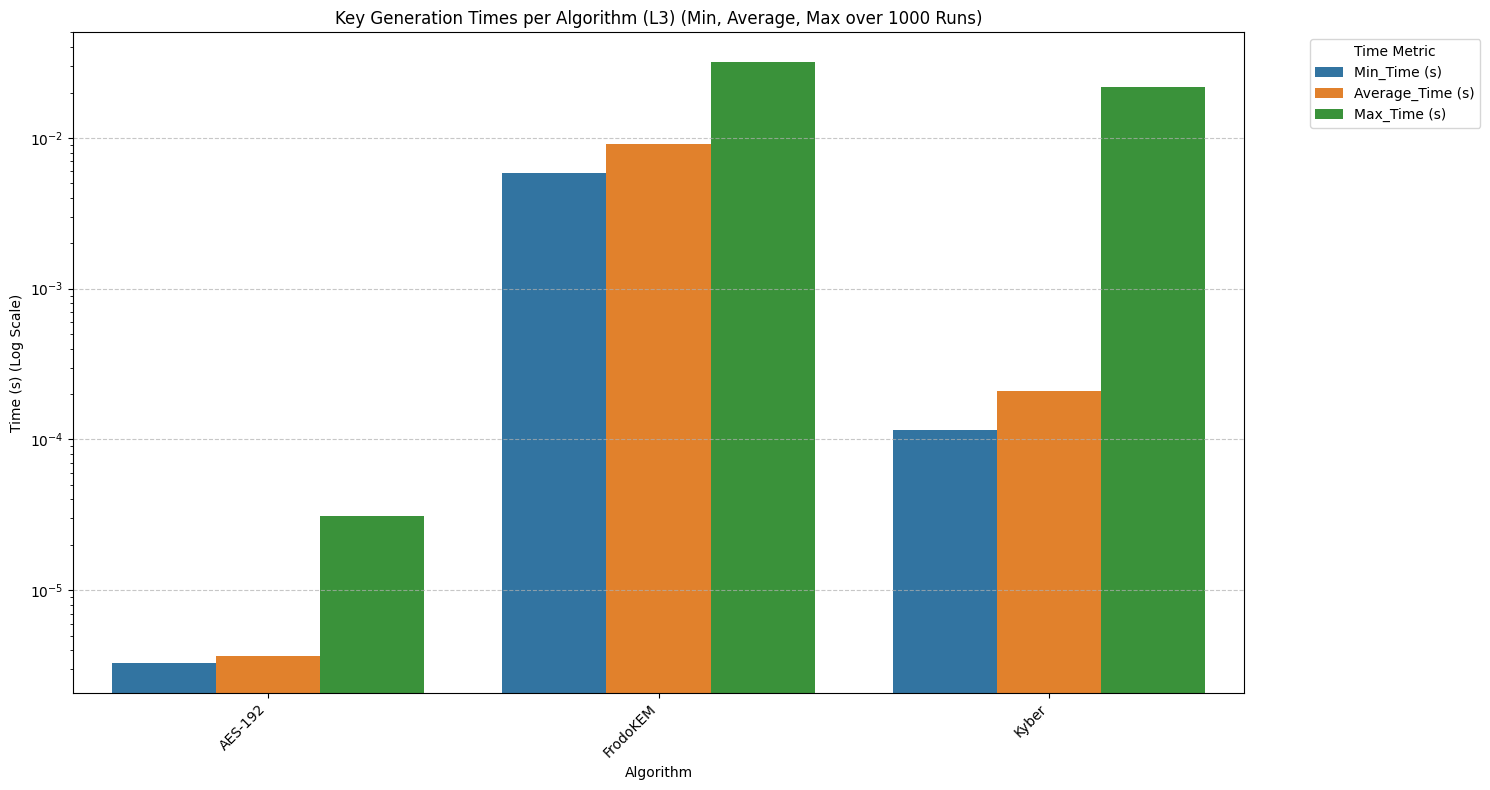

In [19]:
plot_timing_comparison(df_time_keys_L3, test_runs, "Key Generation", 3)


--- Plot: Encryption Times ---


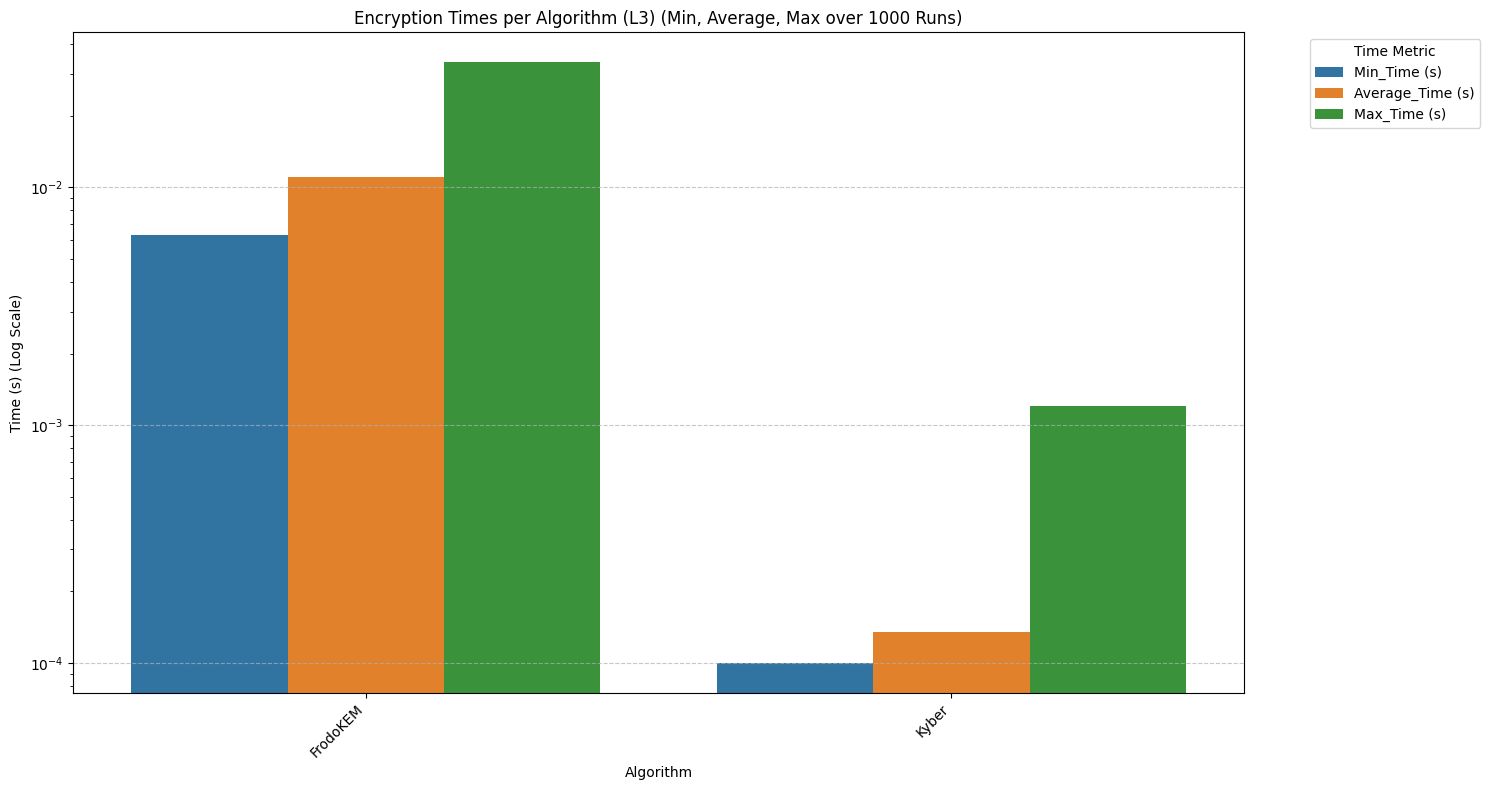

In [20]:
plot_timing_comparison(df_time_encryption_L3, test_runs, "Encryption", 3)


--- Plot: Decryption Times ---


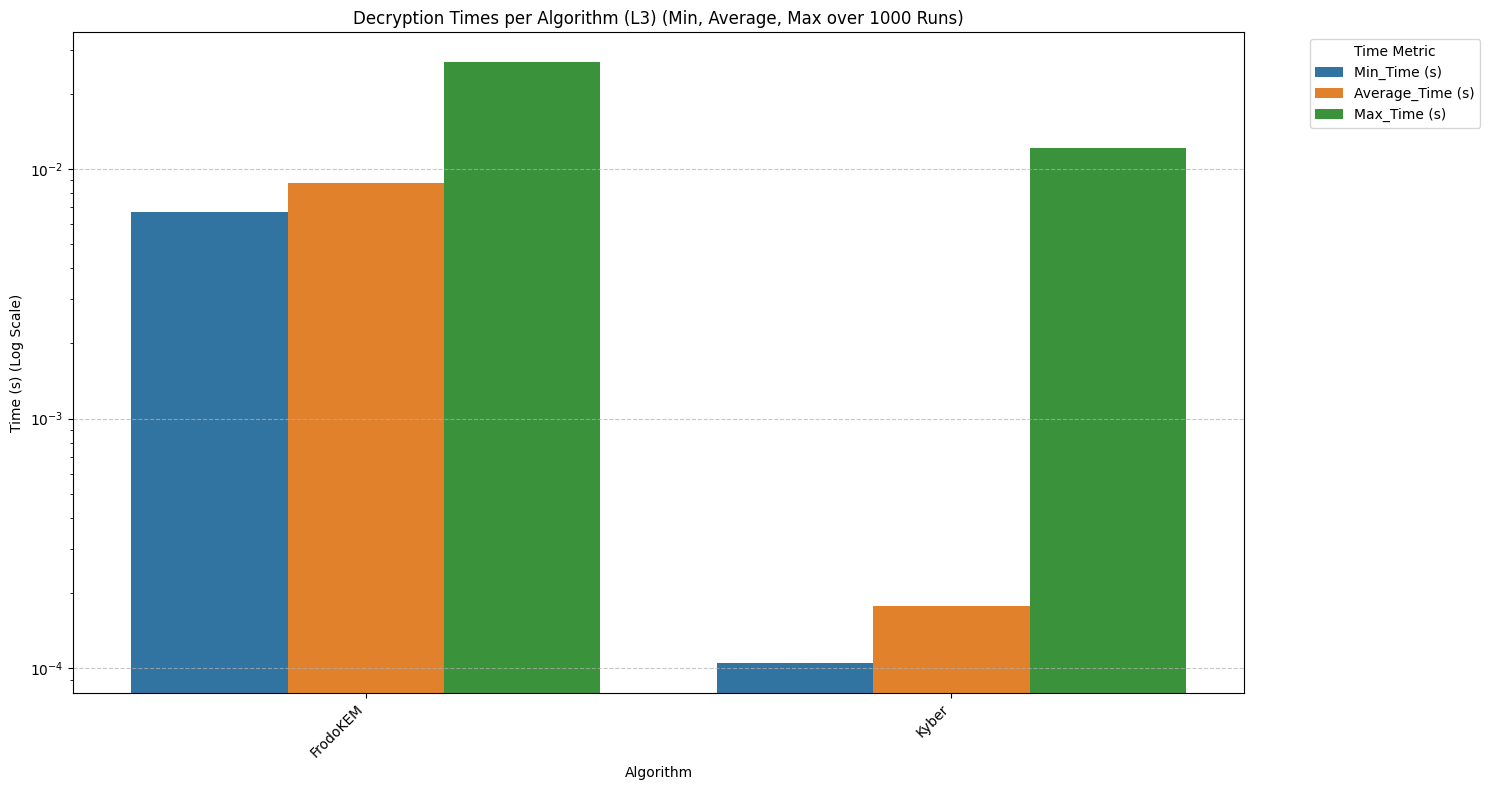

In [21]:
plot_timing_comparison(df_time_decryption_L3, test_runs, "Decryption", 3)

### Level 5 <a id="l5"></a>

In [22]:
print("\nLevel 5...")
df_keys_L5, df_time_keys_L5, df_encryption_L5, df_time_encryption_L5, df_decryption_L5, df_time_decryption_L5 = process_encryption_level(encryption_L5, test_runs, "L5")


Level 5...
Processing ML-KEM...
Shared Secret for ML-KEM (L5) matches: True
Processing FrodoKEM...
Shared Secret for FrodoKEM (L5) matches: True
Processing McEliece...
Shared Secret for McEliece (L5) matches: True
Processing AES-256...


In [23]:
display_results("L5", df_keys_L5, "Generated Keys")
display_results("L5", df_time_keys_L5, "Average Key Generation Times")


--- Generated Keys (L5) ---
  Algorithm Security Level  \
0    ML-KEM             L5   
1  FrodoKEM             L5   
2  McEliece             L5   
3   AES-256             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [24]:
display_results("L5", df_encryption_L5, "Encryption Data")
display_results("L5", df_time_encryption_L5, "Average Encryption Times")


--- Encryption Data (L5) ---
  Algorithm Security Level  \
0    ML-KEM             L5   
1  FrodoKEM             L5   
2  McEliece             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [25]:
display_results("L5", df_decryption_L5, "Decryption Data")
display_results("L5", df_time_decryption_L5, "Average Decryption Times")


--- Decryption Data (L5) ---
  Algorithm Security Level  \
0    ML-KEM             L5   
1  FrodoKEM             L5   
2  McEliece             L5   

                                             Shared Secret Receiver  \
0  e0dab5fa24fe33724a42781c8c4ace7908d178a504d55e1230c255008e4b1a57   
1  6b83a38a228a35574f0c7776443e5c9dadc842b96a40e021f1be9d5edf2d032a   
2  4f6d3e3b451450f5d23bb6485a4d1ad63e712268a35ddd6693464f80ea6ac364   

   Shared Secret Receiver length  
0                             32  
1                             32  
2                             32  

--- Average Decryption Times (L5) ---
  Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0    ML-KEM             L5  Decryption      0.000074          0.000085   
1  FrodoKEM             L5  Decryption      0.007060          0.009351   
2  McEliece             L5  Decryption      0.000163          0.000267   

   Max_Time (s)  
0      0.000184  
1      0.030899  
2      0.021260  



--- Plot: Key Lengths ---


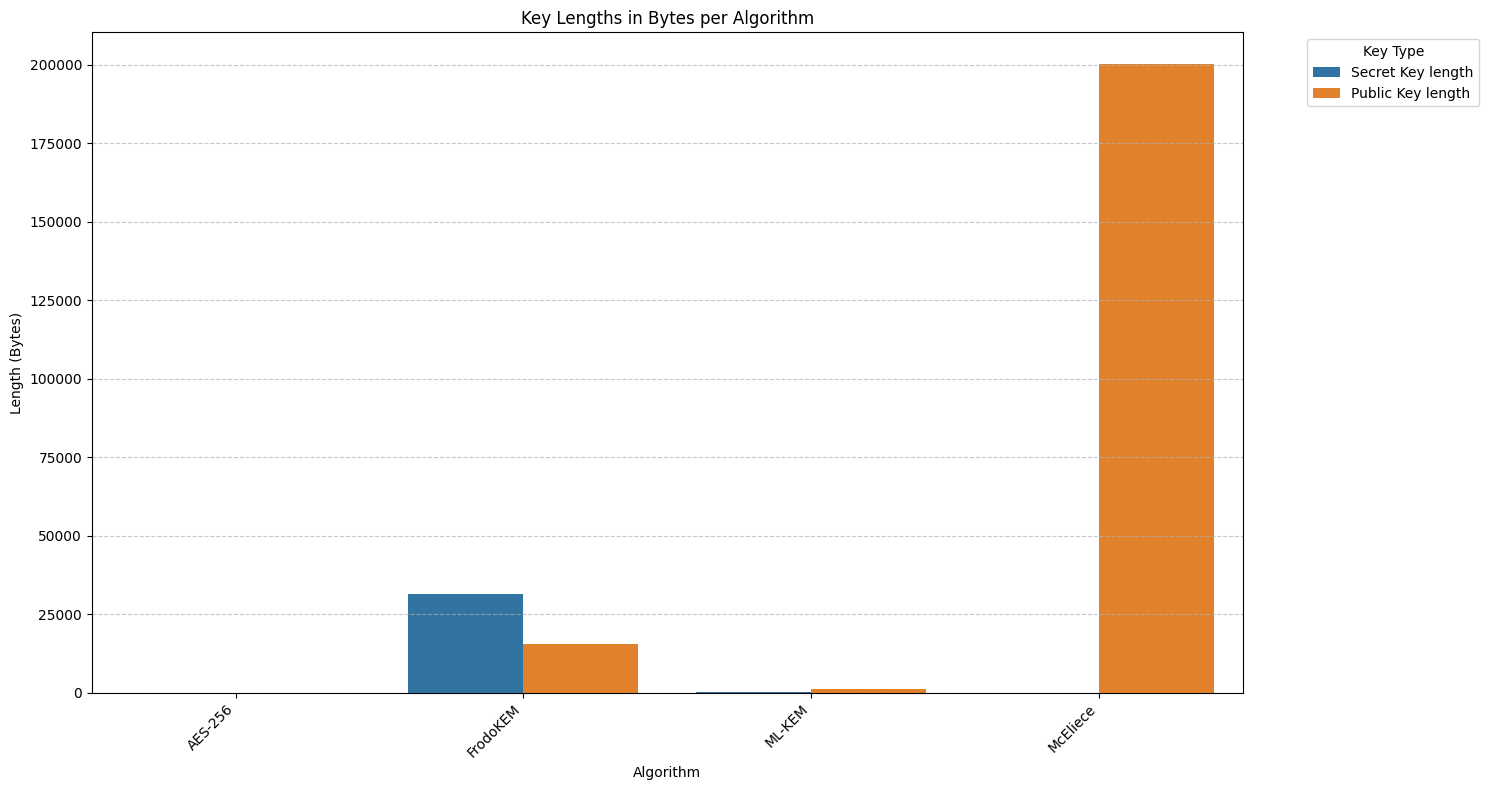

In [26]:
plot_key_length_comparison(df_keys_L5)


--- Plot: Key Generation Times ---


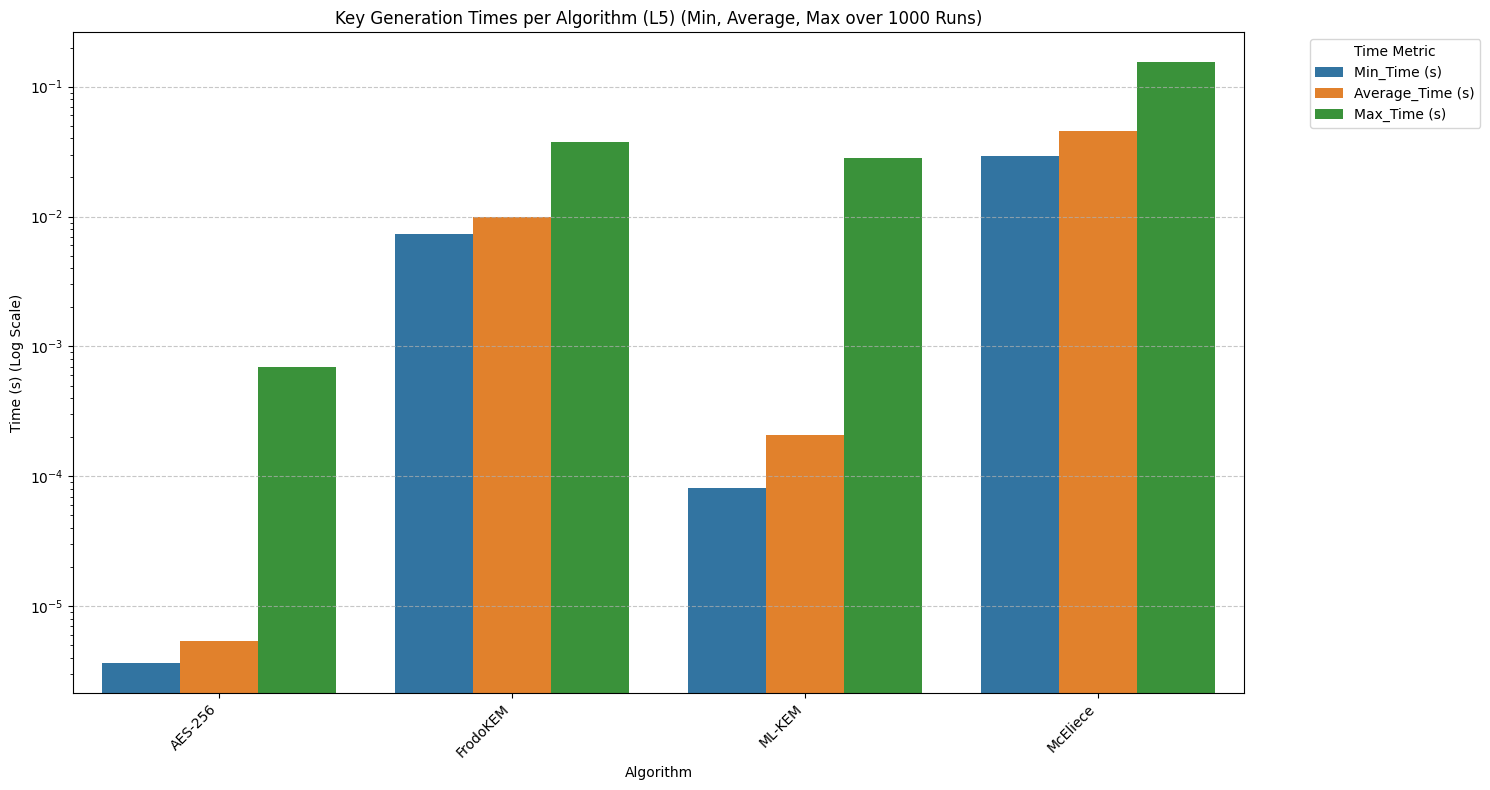

In [27]:
plot_timing_comparison(df_time_keys_L5, test_runs, "Key Generation", 5)


--- Plot: Encryption Times ---


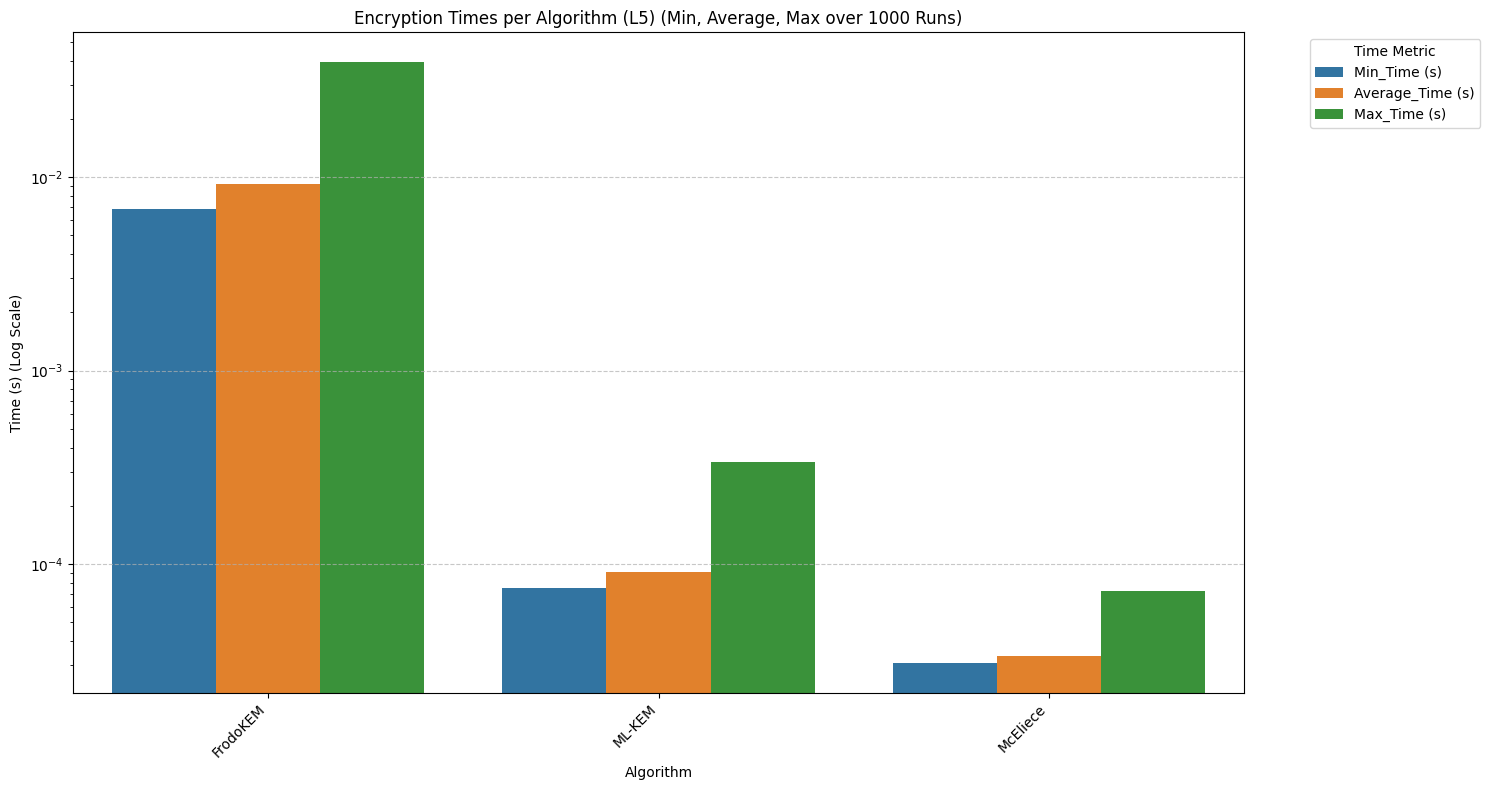

In [28]:
plot_timing_comparison(df_time_encryption_L5, test_runs, "Encryption", 5)


--- Plot: Decryption Times ---


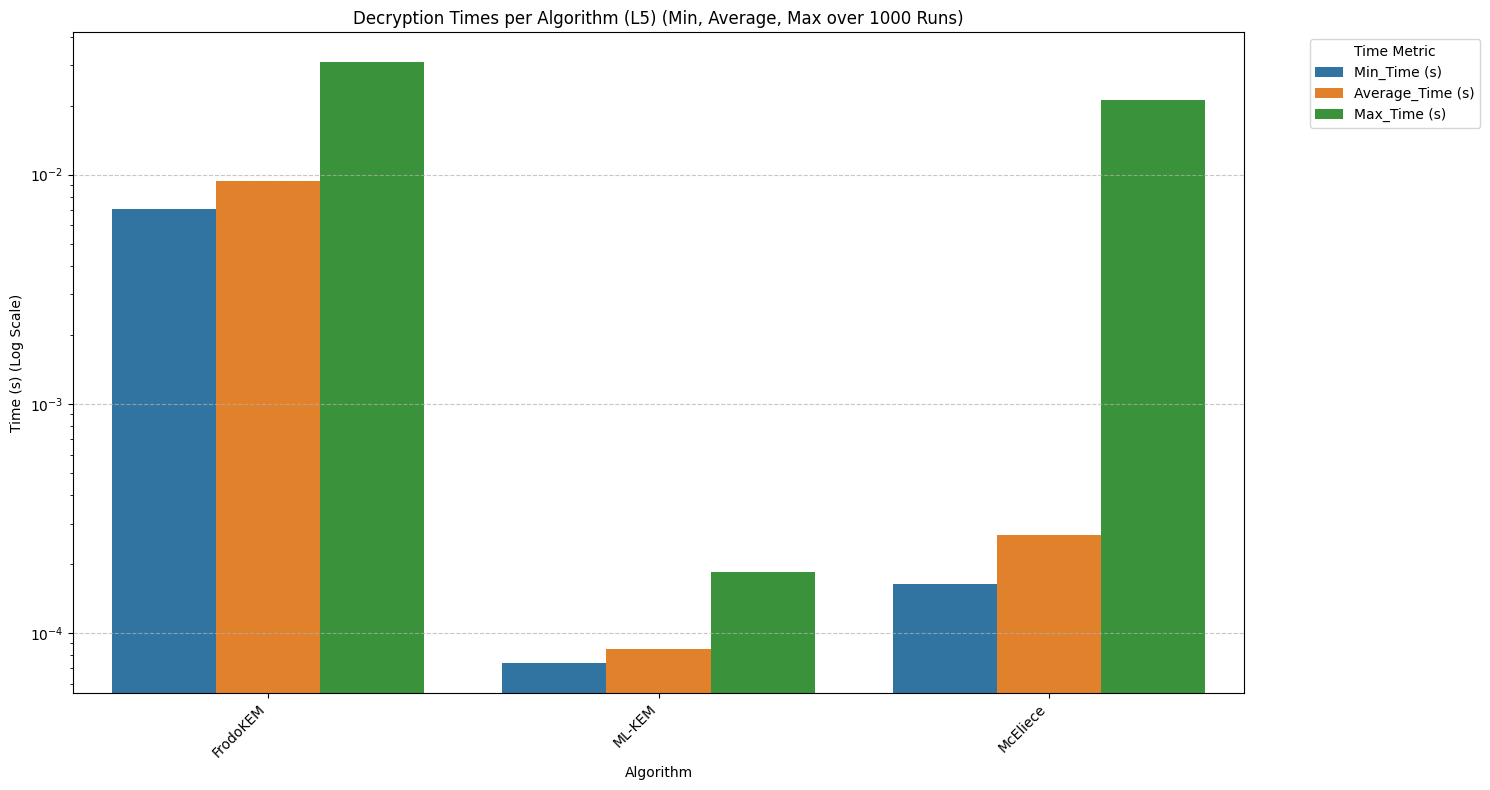

In [29]:
plot_timing_comparison(df_time_decryption_L5, test_runs, "Decryption", 5)

## Conclusion <a id="conclusion"></a>

The performance analysis of selected PQC KEMs reveals **consistent trends** across all NIST Security Levels as well as **consistency** across different libraries. While FrodoKEM and McEliece are featured in this Benchmark, they are not needed to be further analyzed as they are **NOT** NIST standards.